# Assignment 1: From Dirty Data to Predictive Models

## Titanic Survival Prediction

**Course:** Columbia AML  
**Task:** Predict whether a Titanic passenger survived (`Survived` ∈ {0, 1}).

This notebook develops an end-to-end supervised learning workflow covering:
1. Data Cleaning
2. Feature Engineering
3. Model Training (Naive Bayes + Linear Regression)
4. Model Evaluation
5. Discussion and AI Tool Usage Disclosure

> **Notebook goal:** Keep all code, outputs, visualizations, and technical reasoning needed for the final submission in this `.ipynb`.

**Current scope: Step 1 — Data Cleaning.** Steps 2–5 are added in later revisions.

> ## Learning notebook — how to use it
>
> This is the **learning / report-preparation** version of the Step 1 submission notebook. The code is identical to `primary/assign1-titanic_step1_submission.ipynb`; the extra boxes (like this one) are for *you*.
>
> For each section: read the Markdown, predict what the code will show, run it, compare with your prediction, then fill in the **Report notes**.
>
> **Rule from the assignment:** you must be able to explain every block out loud ("Why this imputation? What would break if I removed this line?").

## 0. Setup

This section imports the libraries used in Step 1 and fixes the constants that make the work reproducible.

The modeling dataset is `train.csv`, the only Kaggle file that contains the `Survived` label. We build **our own** train/test split from it, so the held-out portion has known labels for accuracy and confusion-matrix evaluation. Kaggle's `test.csv` has no labels and is not used; `gender_submission.csv` is not required.

> **Learning note — why `RANDOM_STATE` and `TEST_SIZE` are constants**
>
> `train_test_split` shuffles rows randomly. A fixed seed (`42`) makes the shuffle identical on every run, so every model in Steps 3–4 is evaluated on exactly the same held-out passengers. That is what makes the model comparison *fair*.
>
> **Self-test:** What would happen to the comparison if each model used a different random split?

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TEST_SIZE = 0.20

sns.set_theme(style="whitegrid")

### 0.1 Locate the data

The notebook looks for `train.csv` in the working directory (Colab upload) and in the repository's `data/` folder (local run).

In [2]:
candidate_dirs = [Path("."), Path("../../data")]
DATA_DIR = next((d for d in candidate_dirs if (d / "train.csv").exists()), None)
assert DATA_DIR is not None, "train.csv not found. Upload it to the Colab Files panel."

TRAIN_PATH = DATA_DIR / "train.csv"
print(f"Using labeled dataset: {TRAIN_PATH}")

Using labeled dataset: ../../data/train.csv


# 1. Data Loading & Initial Exploration

This section loads the labeled Titanic data and establishes its structure, target distribution, data types, and missing-data profile. These observations drive every cleaning decision in Step 1.

> **Learning note — why inspect before cleaning?**
>
> A workflow is not `load data → fill NaNs → train model`. It is
> `inspect → identify problems → decide what each problem means → choose a defensible treatment → verify`.
>
> **Self-test — for any missing value, can I answer:**
> - What does "missing" mean for this variable?
> - How many are missing, and is dropping rows reasonable?
> - Is imputation reasonable, and could it leak information from the test set?

In [3]:
df = pd.read_csv(TRAIN_PATH)

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


> **Learning note — what you are looking at**
>
> `df` is a pandas **DataFrame**: a table where each row is a passenger and each column a variable. `df.shape` gives `(rows, columns)`.
>
> **Report note:** Dataset size = ______ rows × ______ columns. Target column = ______.

In [4]:
# Schema, non-null counts, and data types.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [5]:
# Numerical summary.
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [6]:
# Categorical summary.
df.describe(include="object").T

,count,unique,top,freq
Name,891,891,"Braund, Mr. Owen Harris",1
Sex,891,2,male,577
Ticket,891,681,347082,7
Cabin,204,147,B96 B98,4
Embarked,889,3,S,644


> **Learning note — reading `info()` and `describe()`**
>
> - `info()` lists non-null counts per column. Anything below the row count has missing values.
> - `describe()` gives count, mean, std, min, quartiles, max. Look for impossible minimums/maximums and for a mean far from the median (skew).
> - Notice `Fare`: mean ≈ 32 but median ≈ 14, and max ≈ 512. That right skew matters for **Step 2** (transformations).
>
> **Self-test:** Which columns are numeric, and which are text/identifier-like?

In [7]:
# Quantify missing values before cleaning.
missing_summary = (
    df.isna()
      .sum()
      .rename("missing_count")
      .to_frame()
      .assign(missing_pct=lambda x: (x["missing_count"] / len(df) * 100).round(2))
      .query("missing_count > 0")
      .sort_values("missing_count", ascending=False)
)

missing_summary

,missing_count,missing_pct
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


**Interpretation.** Three columns contain missing values: `Cabin` (687, 77.10%), `Age` (177, 19.87%) and `Embarked` (2, 0.22%). The three magnitudes call for three different treatments, so no single blanket rule (drop all NaNs, or fill all NaNs) is appropriate.

> **Learning note — why the amount of missingness changes the decision**
>
> | Missing | Rough rule of thumb |
> |---|---|
> | ~0.2% (`Embarked`) | Fill with the most common value; the risk is negligible. |
> | ~20% (`Age`) | Too much to drop (we would lose ~1 in 5 passengers); impute. |
> | ~77% (`Cabin`) | Too sparse to reconstruct; keep only the *fact* that it was recorded. |
>
> **Report note:** Write one sentence per column explaining why *that* treatment fits *that* percentage.

In [8]:
# Target distribution before any transformation.
target_summary = (
    df["Survived"]
      .value_counts()
      .rename_axis("Survived")
      .to_frame("count")
      .assign(percentage=lambda x: (x["count"] / len(df) * 100).round(2))
      .sort_index()
)

target_summary

,count,percentage
Survived,,
0,549,61.62
1,342,38.38


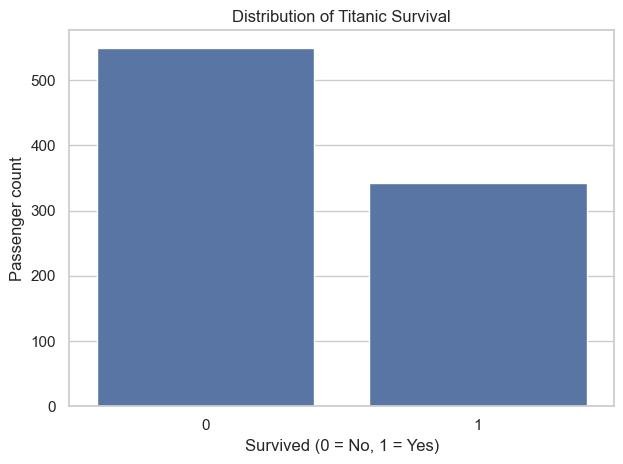

In [9]:
ax = sns.countplot(data=df, x="Survived")
ax.set_title("Distribution of Titanic Survival")
ax.set_xlabel("Survived (0 = No, 1 = Yes)")
ax.set_ylabel("Passenger count")
plt.tight_layout()
plt.show()

**Interpretation.** 549 passengers did not survive (61.62%) and 342 did (38.38%). The classes are moderately imbalanced but not severely so. This justifies a **stratified** train/test split later in this step, so both partitions keep roughly the same survival rate. A trivial "always predict 0" classifier would already score about 61.6% accuracy, which is the baseline any model must beat.

> **Learning note — why the baseline matters**
>
> Accuracy alone can mislead on imbalanced data. Remember 61.62% as the "always predict died" accuracy. In Step 4, any model reporting ~62% is not learning anything useful.
>
> **Report note:** Include the target-distribution plot above in the Introduction/Dataset section of the PDF.

## 2. Step 1 — Data Cleaning

Cleaning is organized into three stages:

1. **Audit** — look for duplicates, inconsistent categorical text, and invalid numeric values. Report honestly what is (and is not) found.
2. **Deterministic cleaning** — fixes that need no learned statistics (text normalization, the `CabinKnown` flag). These are safe to apply before splitting.
3. **Statistical imputation** — fixes that learn a statistic from data (median, most-frequent). These are fitted on the **training split only** to prevent data leakage.

> ## Learning note — what counts as "dirty" data?
>
> Dirty data is not only `NaN`. It also includes inconsistent capitalization/whitespace, impossible numeric values, invalid categories, duplicate records, wrong data types, and valid-but-untransformed values.
>
> **Important:** do not manufacture a problem to satisfy the rubric. If the audit finds no invalid values, say so honestly. The rubric rewards *justified* decisions, not a long list of operations.
>
> **Report note:** For each audit below record: *what was checked → what was found → what action followed*.

In [10]:
# Exact duplicate records.
print(f"Exact duplicate rows: {df.duplicated().sum()}")

Exact duplicate rows: 0


In [11]:
# Expected categorical domains, after trimming and case-folding.
categorical_checks = {
    "Sex": sorted(df["Sex"].dropna().str.strip().str.lower().unique().tolist()),
    "Embarked": sorted(df["Embarked"].dropna().str.strip().str.upper().unique().tolist()),
}

categorical_checks

{'Sex': ['female', 'male'], 'Embarked': ['C', 'Q', 'S']}

In [12]:
# Obviously invalid numeric or domain values.
numeric_quality_checks = {
    "Age_below_zero": int((df["Age"].dropna() < 0).sum()),
    "Fare_below_zero": int((df["Fare"].dropna() < 0).sum()),
    "SibSp_below_zero": int((df["SibSp"].dropna() < 0).sum()),
    "Parch_below_zero": int((df["Parch"].dropna() < 0).sum()),
    "invalid_Pclass": int((~df["Pclass"].dropna().isin([1, 2, 3])).sum()),
    "invalid_Survived": int((~df["Survived"].dropna().isin([0, 1])).sum()),
}

pd.Series(numeric_quality_checks, name="invalid_count").to_frame()

,invalid_count
Age_below_zero,0
Fare_below_zero,0
SibSp_below_zero,0
Parch_below_zero,0
invalid_Pclass,0
invalid_Survived,0


In [13]:
# Zero fares are not negative, but are worth documenting.
df.loc[df["Fare"] == 0].groupby("Pclass").size().rename("zero_fare_count").to_frame()

,zero_fare_count
Pclass,
1,5
2,6
3,4


**Audit findings.**

- **Duplicates:** none, so no rows are removed.
- **Categorical domains:** `Sex` ∈ {female, male} and `Embarked` ∈ {C, Q, S}. No typos or rogue categories exist. Normalization of whitespace/case is still applied defensively so that later encoders cannot split one category into two.
- **Numeric validity:** every check returns 0. There is **no noisy or invalid numeric data to correct**, and none is invented.
- **Zero fares:** 15 passengers (5 first-, 6 second-, 4 third-class) have `Fare == 0`. A zero is not impossible (it may reflect complimentary or unrecorded tickets) and cannot be verified from the data, so these values are **left unchanged**. Fare's skew is addressed by transformation in Step 2.

> **Learning note — "no problems found" is a valid result**
>
> A clean audit is still evidence: it lets the report state *"we checked X, Y, Z and found nothing to fix"* instead of silently skipping the check.
>
> **Self-test:** Why did we *not* replace the 15 zero fares with a median? (Hint: we cannot show they are errors, and altering real values without evidence is itself a form of noise.)
>
> **Report note:** The audit table above can be reproduced as a small "Data Quality Audit" table in the Data Cleaning section.

### 2.1 Deterministic cleaning

`Sex`, `Embarked` and `Cabin` are trimmed and case-normalized. Missing values are preserved at this point; nothing is filled yet.

In [14]:
clean = df.copy()

clean["Sex"] = clean["Sex"].str.strip().str.lower()
clean["Embarked"] = clean["Embarked"].str.strip().str.upper()
clean["Cabin"] = clean["Cabin"].str.strip()

clean[["Sex", "Embarked", "Cabin"]].head()

,Sex,Embarked,Cabin
0,male,S,NaN
1,female,C,C85
2,female,S,NaN
3,female,S,C123
4,male,S,NaN


### 2.2 `CabinKnown` flag

`Cabin` is missing for 77.10% of passengers, so reconstructing cabin identifiers would mean inventing most of them. Instead, whether a cabin was **recorded** is kept as a binary feature. It is derived from the row itself and uses no statistics from other rows or from the target, so it is safe to compute before the split.

In [15]:
clean["CabinKnown"] = clean["Cabin"].notna().astype(int)

clean["CabinKnown"].value_counts().rename_axis("CabinKnown").to_frame("count").sort_index()

,count
CabinKnown,
0,687
1,204


> **Learning note — missingness can carry information**
>
> Cabin numbers were mostly recorded for passengers in better-documented (largely higher-class) records. So "missing" is not random noise: it can be a signal, and `CabinKnown` converts it into a usable numeric feature. The survival-rate table in Section 3 checks this on the training data instead of assuming it.
>
> **Caution to be able to explain:** `CabinKnown` is correlated with `Pclass`, so part of its effect may already be explained by class. We keep it because the assignment asks us to justify flagging vs. dropping, and we discuss the overlap in the report.
>
> **Self-test:** Why is it OK to compute this *before* the split, while the median Age is not?

## 3. Train/Test Split

The split is performed **before** any statistic is learned. It is stratified on `Survived` so that both partitions retain the original ~38% survival rate. This single split is reused unchanged by every model in Steps 3–4.

In [16]:
X = clean.drop(columns="Survived")
y = clean["Survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

pd.DataFrame(
    {
        "rows": [len(y_train), len(y_test)],
        "survival_rate_pct": [round(y_train.mean() * 100, 2), round(y_test.mean() * 100, 2)],
    },
    index=["train", "test"],
)

,rows,survival_rate_pct
train,712,38.34
test,179,38.55


**Interpretation.** The split has 712 training and 179 test rows with survival rates of 38.34% and 38.55%, so stratification preserved the class balance.

> **Learning note — what `train_test_split` returns and why the target is separated**
>
> - `X` holds the input columns, `y` the answer. `Survived` is removed from `X` so it can never be used as an input.
> - `stratify=y` keeps the same proportion of survivors in both parts.
> - The 20% test set is "the exam": it must stay unseen until evaluation.
>
> **Self-test:** If we imputed Age using the median of all 891 rows and *then* split, what information would the training data have seen about the test passengers?

Missing values are inspected again within each partition, and the `CabinKnown` signal is examined on the **training** partition only.

In [17]:
imputation_columns = ["Age", "Embarked"]

pd.DataFrame(
    {
        "train_missing": X_train[imputation_columns].isna().sum(),
        "test_missing": X_test[imputation_columns].isna().sum(),
    }
)

,train_missing,test_missing
Age,137,40
Embarked,2,0


In [18]:
(
    pd.concat([X_train["CabinKnown"], y_train], axis=1)
      .groupby("CabinKnown")["Survived"]
      .agg(passengers="size", survival_rate="mean")
      .round(3)
)

,passengers,survival_rate
CabinKnown,,
0,552,0.292
1,160,0.700


**Interpretation.** Missing `Age` appears in 137 training and 40 test rows; missing `Embarked` appears in 2 training rows and none in the test rows. On the training partition, passengers with a recorded cabin survived at 70.0% versus 29.2% for those without, so the cabin-availability flag carries real signal and is worth retaining.

## 4. Leakage-Safe Imputation

| Column | Strategy | Rationale |
|---|---|---|
| `Age` | Median of the training split | Retains ~20% of passengers that dropping would discard. The median is robust to the right-skewed age distribution and to outliers. |
| `Embarked` | Most frequent category of the training split | Only 2 missing values in a categorical variable; the mode is the least intrusive fill. |

Each imputer is **fitted on `X_train` only**, then used to **transform** both partitions. The test partition therefore never influences the statistics.

> **Learning note — `fit` vs. `transform` (a likely oral-exam question)**
>
> - `imputer.fit(X_train)` *learns* a statistic (the median age / most frequent port) from the training data.
> - `imputer.transform(X)` *applies* that stored statistic to fill gaps in whatever data it is given.
> - `fit_transform(X_train)` does both on training data. For the test data we call **only** `transform(X_test)`, so a test passenger's age never changes the number used to fill any gap.
>
> **Why median, not mean?** Age is mildly right-skewed (a few elderly passengers pull the mean up). The median is less sensitive.
>
> **Alternatives considered:** dropping rows with missing Age (loses ~20% of data); mean imputation (more sensitive to skew); group-wise medians by title/class (more accurate but more complex, a possible extension, not required here); model-based imputation (overkill for this assignment).
>
> **What could go wrong:** median imputation shrinks the variance of Age (see the plot below) and ignores relationships with other variables.

In [19]:
age_imputer = SimpleImputer(strategy="median").fit(X_train[["Age"]])
embarked_imputer = SimpleImputer(strategy="most_frequent").fit(X_train[["Embarked"]])

pd.Series(
    {
        "Age median (training split)": age_imputer.statistics_[0],
        "Embarked mode (training split)": embarked_imputer.statistics_[0],
    },
    name="learned_value",
).to_frame()

,learned_value
Age median (training split),28.5
Embarked mode (training split),S


In [20]:
def apply_imputers(features):
    imputed = features.copy()
    imputed["Age"] = age_imputer.transform(imputed[["Age"]]).ravel()
    imputed["Embarked"] = embarked_imputer.transform(imputed[["Embarked"]]).ravel()
    return imputed


X_train_clean = apply_imputers(X_train)
X_test_clean = apply_imputers(X_test)

### 4.1 Verification

The following checks confirm that the imputed columns are complete in both partitions, that no rows were dropped or reordered, and that the target did not leak into the features.

In [21]:
checked_columns = ["Age", "Embarked", "CabinKnown"]

assert X_train_clean[checked_columns].notna().all().all()
assert X_test_clean[checked_columns].notna().all().all()
assert "Survived" not in X_train_clean.columns and "Survived" not in X_test_clean.columns
assert X_train_clean.index.equals(X_train.index) and X_test_clean.index.equals(X_test.index)
assert len(X_train_clean) + len(X_test_clean) == len(df)

pd.concat(
    {
        "train": pd.DataFrame(
            {"before": X_train[imputation_columns].isna().sum(),
             "after": X_train_clean[imputation_columns].isna().sum()}
        ),
        "test": pd.DataFrame(
            {"before": X_test[imputation_columns].isna().sum(),
             "after": X_test_clean[imputation_columns].isna().sum()}
        ),
    },
    axis=1,
)

train         test      
         before after before after
Age         137     0     40     0
Embarked      2     0      0     0

### 4.2 Before/after evidence

Individual records, and the effect on the `Age` distribution of the training partition.

In [22]:
(
    pd.DataFrame({"Age_before": X_train["Age"], "Age_after": X_train_clean["Age"]})
      .loc[X_train["Age"].isna()]
      .head(5)
)

,Age_before,Age_after
692,NaN,28.5
481,NaN,28.5
527,NaN,28.5
557,NaN,28.5
828,NaN,28.5


In [23]:
embarked_before = pd.concat([X_train, X_test])["Embarked"]
embarked_after = pd.concat([X_train_clean, X_test_clean])["Embarked"]

(
    pd.DataFrame({"Embarked_before": embarked_before, "Embarked_after": embarked_after})
      .loc[embarked_before.isna()]
      .assign(split=lambda t: ["train" if i in X_train.index else "test" for i in t.index])
)

,Embarked_before,Embarked_after,split
829,NaN,S,train
61,NaN,S,train


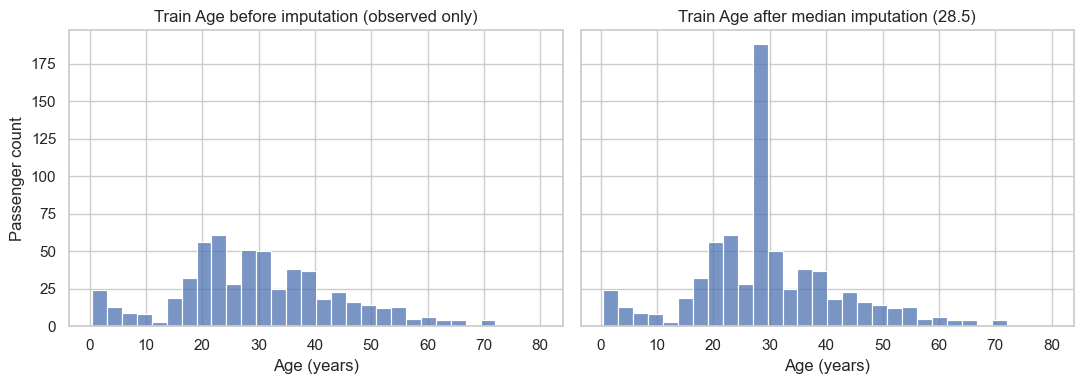

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

sns.histplot(X_train["Age"].dropna(), bins=30, ax=axes[0])
axes[0].set_title("Train Age before imputation (observed only)")

sns.histplot(X_train_clean["Age"], bins=30, ax=axes[1])
axes[1].set_title(f"Train Age after median imputation ({age_imputer.statistics_[0]:.1f})")

for ax in axes:
    ax.set_xlabel("Age (years)")
axes[0].set_ylabel("Passenger count")

plt.tight_layout()
plt.show()

In [25]:
pd.DataFrame(
    {
        "before": X_train["Age"].describe(),
        "after": X_train_clean["Age"].describe(),
    }
).round(2)

,before,after
count,575.00,712.00
mean,29.81,29.56
std,14.49,13.03
min,0.42,0.42
25%,21.00,22.00
50%,28.50,28.50
75%,39.00,36.00
max,80.00,80.00


**Interpretation.** All gaps in `Age` and `Embarked` are filled in both partitions, and row counts are unchanged (712 + 179 = 891). The learned fill values are an Age of 28.5 years and port `S` (Southampton, the most common port). The histogram shows the main side effect of median imputation: a spike at the median and a narrower standard deviation than the observed ages. This is an accepted trade-off for keeping 137 + 40 passengers, and is recorded as a limitation for the Discussion section.

> **Learning note — reading the before/after plot**
>
> Before: a smooth age distribution of the 575 observed training ages. After: the same shape plus a tall bar at ≈ 28.5, because 137 missing values were all given the same number.
>
> **Report note:** Embed this two-panel figure in the Data Cleaning section and explain the spike and the shrunken standard deviation as an honest limitation.
>
> **Self-test (pick two and answer out loud):**
> 1. Why is the median fitted on `X_train` and not on `X`?
> 2. What would happen to the variance of Age if 90% of values were imputed?
> 3. Why do we keep rows instead of dropping them?
> 4. Why use `most_frequent` for `Embarked` but `median` for `Age`?
> 5. What would break if `Survived` stayed inside `X`?

## 5. Cleaning Decisions and Step 1 Checkpoint

| Variable | Problem found | Decision | Rationale |
|---|---|---|---|
| `Age` | 19.87% missing | Median imputation, fitted on the training split only | Keeps ~1 in 5 passengers; median is robust to skew; no test leakage |
| `Embarked` | 0.22% missing (2 rows) | Most-frequent imputation, fitted on the training split only | Negligible missingness in a categorical variable |
| `Cabin` | 77.10% missing | Not imputed; `CabinKnown` flag created | Too sparse to reconstruct without inventing values; availability itself is informative |
| `Sex`, `Embarked`, `Cabin` | Possible whitespace/case inconsistencies | Trimmed; `Sex` lower-cased, `Embarked` upper-cased | Prevents one category being split into several by encoders |
| Numeric/target fields | No negative or out-of-domain values | No correction | Audit found no violations |
| `Fare` | 15 zero values | Left unchanged | Zero is not demonstrably invalid; skew handled in Step 2 |
| Duplicates | None found | No rows removed | Nothing to remove |
| `Survived` | Complete and valid | Kept as target only | Never used as an input feature |

**Deferred to Step 2 (Feature Engineering):** whether and how to use `PassengerId` (identifier, expected to be excluded), `Name` (candidate `Title`), `Ticket` (high-cardinality identifier), the raw `Cabin` string (expected to be dropped in favor of `CabinKnown`), categorical encoding, and scaling/log-transformation.

**Outputs handed to Step 2:** `X_train_clean`, `X_test_clean`, `y_train`, `y_test`, all produced with a single stratified split (`test_size = 0.20`, `random_state = 42`).

In [26]:
X_train_clean.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,CabinKnown
692,693,3,"Lam, Mr. Ali",male,28.5,0,0,1601,56.4958,NaN,S,0
481,482,2,"Frost, Mr. Anthony Wood ""Archie""",male,28.5,0,0,239854,0.0000,NaN,S,0
527,528,1,"Farthing, Mr. John",male,28.5,0,0,PC 17483,221.7792,C95,S,1
855,856,3,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,NaN,S,0
801,802,2,"Collyer, Mrs. Harvey (Charlotte Annie Tate)",female,31.0,1,1,C.A. 31921,26.2500,NaN,S,0


## Step 1 — Personal learning & report checklist

Before moving on, I should be able to explain:

- [ ] What a DataFrame is, and what `df.info()` / `df.describe()` tell me.
- [ ] What `NaN` means, and why missing values must be handled before modeling.
- [ ] Why the amount of missingness (0.22% / 19.87% / 77.10%) leads to three different treatments.
- [ ] What data leakage is, and why imputation statistics come from the training split only.
- [ ] The difference between `fit`, `transform` and `fit_transform`.
- [ ] Why the audit found nothing to fix in the numeric fields, and why I did not invent problems.
- [ ] Why `CabinKnown` is safe to compute before the split.
- [ ] Why `Survived` must never be an input feature.
- [ ] The side effect of median imputation (spike + reduced variance).

### Report notes to fill in (Data Cleaning section, PDF)

- Dataset size and target balance: ______
- Missing-value findings (Cabin / Age / Embarked): ______
- Audit results (duplicates, categorical domains, numeric validity, zero fares): ______
- Decision and justification per variable (impute vs. drop vs. flag): ______
- Before/after evidence to embed: Age histogram pair; missing-count table; Age/Embarked example rows: ______
- Limitations to mention: median spike / reduced variance; `CabinKnown` overlaps with `Pclass`; only one split used (variance of the estimate): ______
- AI disclosure notes for this step (what AI proposed vs. what I reviewed/changed): ______

### Rubric reminder

Data Cleaning & Transformation is **20%** of the grade: *clear handling of missing, noisy and inconsistent data with justification.* The justification matters more than the number of operations.